In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import seaborn as sns

from network_original_lpn import LPN
from network_ne_by_norm import NE_LPN_By_Norm
from network_scale_equiv_by_design import Scale_LPN_By_Design
from utils import prox, cvx, prior, gt_cvx_split_normal, split_normal_log_prior, prox_split_normal

MODEL_DIR = "experiments/models/"
PLOT_DIR = "experiments/plots/"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
sns.set()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

np.random.seed(1)
torch.manual_seed(1)

In [2]:
def add_noise(x, sigma=0.1):
    return x + torch.randn_like(x) * sigma

In [3]:
def exp_func(x, gamma):
    return -torch.exp(-((x / gamma) ** 2)) + 1

In [4]:
class SplitNormalSampler:
    def __init__(self, mean: float = 0.0, std_left: float = 1.0, std_right: float = 2.0):
        self.mean = mean
        self.std_left = std_left
        self.std_right = std_right
        self.p_left = std_left / (std_left + std_right)

    def __call__(self, n: int):
        u = torch.rand(n)
        z = torch.randn(n).abs()
        samples = torch.where(
            u < self.p_left,
            self.mean - z * self.std_left,
            self.mean + z * self.std_right
        )
        return samples

In [5]:
def single_iteration(model, bsize, sigma_noise, optimizer, sampler, loss_type, gamma_loss=None):
    target = sampler(bsize).unsqueeze(1).to(device)
    input_ = add_noise(target, sigma_noise).to(device)
    output = model(input_)

    if loss_type == 2:
        loss = torch.nn.functional.mse_loss(output, target)
    elif loss_type == 1:
        loss = torch.nn.functional.l1_loss(output, target)
    elif loss_type == 0:
        loss = exp_func(output - target, gamma_loss).mean()
    else:
        raise ValueError("Invalid loss_type")

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if hasattr(model, "wclip"):
        model.wclip()
    return loss.item()


In [6]:
def plot_all(model, title, mean=0.0, stdev_right=2.0, stdev_left=1.0):
    xi = np.linspace(-8, 8, 1000)
    y = prox(xi, model)
    c = cvx(xi, model)
    p = prior(xi, model)

    fig, axs = plt.subplots(1, 3, figsize=(8, 3))
    axs[0].plot(xi, y, label="LPN")
    axs[0].plot(xi, prox_split_normal(xi), '--', label="split normal prox")
    axs[0].set_title("Learned prox")
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(xi, c - c.min(), label="Cvx func")
    axs[1].plot(xi, gt_cvx_split_normal(xi), '--', label="ref.")
    axs[1].set_title("Cvx func")
    axs[1].grid(True)
    axs[1].legend()

    axs[2].plot(xi, p - p.min(), label="LPN")
    axs[2].plot(xi, split_normal_log_prior(xi, mean, stdev_left, stdev_right), '--', label="split normal log-prior")
    axs[2].set_title("Original func")
    axs[2].grid(True)
    axs[2].legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{title}_plot.png"))
    plt.show()

In [ ]:
def plot_comparison(models, mean=0.0, stdev_right=2.0, stdev_left=1.0):
    xi = np.linspace(-8, 8, 1000)

    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2])

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, :])

    for name, model in models.items():
        y = prox(xi, model)
        c = cvx(xi, model)
        p = prior(xi, model)

        ax1.plot(xi, y, label=name)
        ax2.plot(xi, c - c.min(), label=name)
        ax3.plot(xi, p - p.min(), label=name)

    ax1.plot(
        xi,
        prox_split_normal(xi),
        "--",
        label=r"$\mathcal{SN}(0,1,2)$ proximal operator",
    )
    ax1.set_title(r"Learned proximal $\nabla f_\theta$")

    ax2.plot(xi, gt_cvx_split_normal(xi), "--", label="Reference")
    ax2.set_title(r"Convex function $f_\theta$")

    ax3.plot(
        xi,
        split_normal_log_prior(xi, mean, stdev_left, stdev_right),
        "--",
        label=r"$\mathcal{SN}(0,1,2)$ log-prior",
    )
    ax3.set_title(r"Log-prior $R_\theta$")

    for ax in [ax1, ax2, ax3]:
        ax.grid(True, alpha=0.3)

    handles, labels = ax3.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        bbox_to_anchor=(0.98, 0.02),
        loc="lower right",
        frameon=True,
        fancybox=True,
        shadow=True,
    )

    plt.suptitle("Model Comparison", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(
        os.path.join(PLOT_DIR, "model_comparison_square.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

In [8]:
def train_model(model, model_name, loss_type, gamma_loss, sampler, sigma_noise, 
                lr_schedule, iterations_per_phase):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_schedule[0])
    bsize = 2000
    loss_log = []

    print(f"Training {model_name}...")
    for phase, lr in enumerate(lr_schedule):
        for g in optimizer.param_groups:
            g['lr'] = lr
        for i in range(iterations_per_phase):
            loss = single_iteration(model, bsize, sigma_noise, optimizer, sampler, loss_type, gamma_loss)
            if i % 100 == 0:
                print(f"{model_name} | Phase {phase+1}/{len(lr_schedule)} | Iter {i}: Loss = {loss:.6f}")
                loss_log.append(loss)

    # Save and plot
    model_path = os.path.join(MODEL_DIR, f"{model_name}.pth")
    torch.save(model.state_dict(), model_path)
    plot_all(model, title=model_name)
    return model
    

In [9]:
mean, std_left, std_right = 0.0, 1.0, 2.0
sampler = SplitNormalSampler(mean=mean, std_left=std_left, std_right=std_right) 
sigma_noise = 1.0
loss_type = 0
gamma_loss = 0.1
lr_schedule = [1e-3, 1e-4]
iterations_per_phase = 10000

In [10]:
dim = 1
hidden = 50
layers = 4
beta = 10

In [11]:
def get_models():
    return {
        "Equivariant by Design": Scale_LPN_By_Design(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
        "Equivariant by Normalization Trick": NE_LPN_By_Norm(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
        "Original LPN": LPN(in_dim=dim, hidden=hidden, layers=layers, beta=beta),
    }

Training Equivariant by Design...
Equivariant by Design | Phase 1/2 | Iter 0: Loss = 0.984173
Equivariant by Design | Phase 1/2 | Iter 100: Loss = 0.998501
Equivariant by Design | Phase 1/2 | Iter 200: Loss = 0.993378
Equivariant by Design | Phase 1/2 | Iter 300: Loss = 0.997205
Equivariant by Design | Phase 1/2 | Iter 400: Loss = 0.993027
Equivariant by Design | Phase 1/2 | Iter 500: Loss = 0.940495
Equivariant by Design | Phase 1/2 | Iter 600: Loss = 0.941995
Equivariant by Design | Phase 1/2 | Iter 700: Loss = 0.931996
Equivariant by Design | Phase 1/2 | Iter 800: Loss = 0.932602
Equivariant by Design | Phase 1/2 | Iter 900: Loss = 0.945175
Equivariant by Design | Phase 1/2 | Iter 1000: Loss = 0.921434
Equivariant by Design | Phase 1/2 | Iter 1100: Loss = 0.928316
Equivariant by Design | Phase 1/2 | Iter 1200: Loss = 0.928466
Equivariant by Design | Phase 1/2 | Iter 1300: Loss = 0.927449
Equivariant by Design | Phase 1/2 | Iter 1400: Loss = 0.928319
Equivariant by Design | Phase 1/2

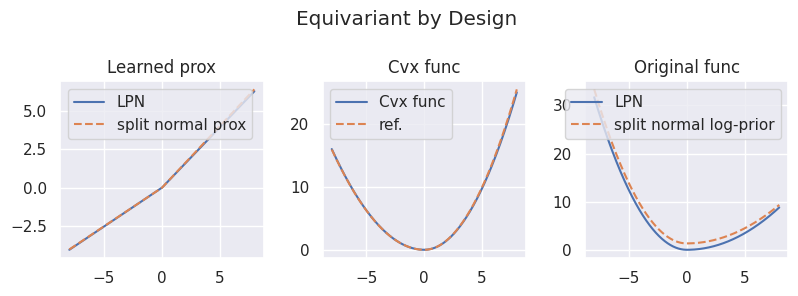

Training Equivariant by Normalization Trick...
Equivariant by Normalization Trick | Phase 1/2 | Iter 0: Loss = 0.945514
Equivariant by Normalization Trick | Phase 1/2 | Iter 100: Loss = 0.909060
Equivariant by Normalization Trick | Phase 1/2 | Iter 200: Loss = 0.921560
Equivariant by Normalization Trick | Phase 1/2 | Iter 300: Loss = 0.918375
Equivariant by Normalization Trick | Phase 1/2 | Iter 400: Loss = 0.919159
Equivariant by Normalization Trick | Phase 1/2 | Iter 500: Loss = 0.912398
Equivariant by Normalization Trick | Phase 1/2 | Iter 600: Loss = 0.912217
Equivariant by Normalization Trick | Phase 1/2 | Iter 700: Loss = 0.919446
Equivariant by Normalization Trick | Phase 1/2 | Iter 800: Loss = 0.916457
Equivariant by Normalization Trick | Phase 1/2 | Iter 900: Loss = 0.914469
Equivariant by Normalization Trick | Phase 1/2 | Iter 1000: Loss = 0.918389
Equivariant by Normalization Trick | Phase 1/2 | Iter 1100: Loss = 0.903475
Equivariant by Normalization Trick | Phase 1/2 | Iter

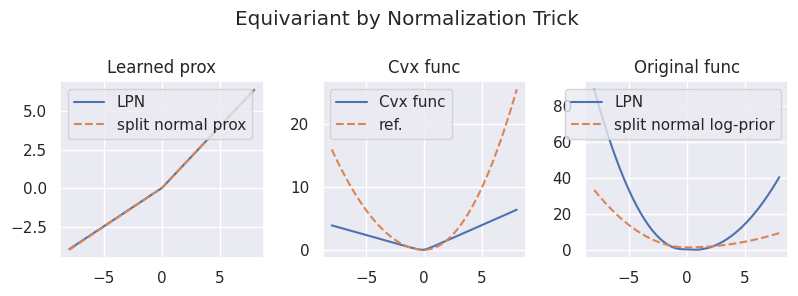

Training Original LPN...
Original LPN | Phase 1/2 | Iter 0: Loss = 0.962492
Original LPN | Phase 1/2 | Iter 100: Loss = 0.922664
Original LPN | Phase 1/2 | Iter 200: Loss = 0.926014
Original LPN | Phase 1/2 | Iter 300: Loss = 0.917082
Original LPN | Phase 1/2 | Iter 400: Loss = 0.921259
Original LPN | Phase 1/2 | Iter 500: Loss = 0.919589
Original LPN | Phase 1/2 | Iter 600: Loss = 0.928320
Original LPN | Phase 1/2 | Iter 700: Loss = 0.923325
Original LPN | Phase 1/2 | Iter 800: Loss = 0.907581
Original LPN | Phase 1/2 | Iter 900: Loss = 0.916370
Original LPN | Phase 1/2 | Iter 1000: Loss = 0.914142
Original LPN | Phase 1/2 | Iter 1100: Loss = 0.917752
Original LPN | Phase 1/2 | Iter 1200: Loss = 0.909464
Original LPN | Phase 1/2 | Iter 1300: Loss = 0.912003
Original LPN | Phase 1/2 | Iter 1400: Loss = 0.922085
Original LPN | Phase 1/2 | Iter 1500: Loss = 0.917343
Original LPN | Phase 1/2 | Iter 1600: Loss = 0.919094
Original LPN | Phase 1/2 | Iter 1700: Loss = 0.926049
Original LPN | 

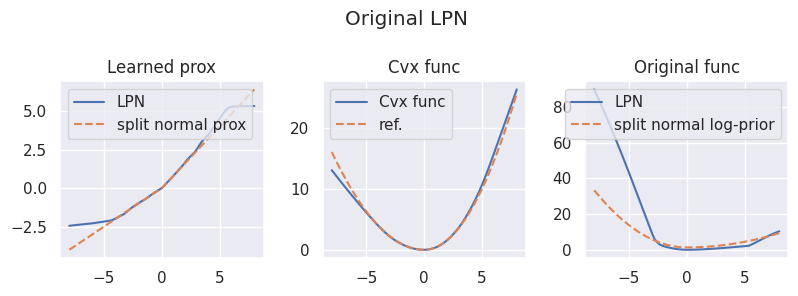

In [12]:
trained_models = {}
for name, model in get_models().items():
    trained_models[name] = train_model(model, name, loss_type, gamma_loss, 
                                       sampler=sampler, sigma_noise=sigma_noise, 
                                       lr_schedule=lr_schedule, iterations_per_phase=iterations_per_phase)

mse 21.38268280029297
mse 16.848520278930664
mse 13.28725814819336
mse 10.441605567932129
mse 8.17876148223877
mse 6.385039806365967
mse 4.967698574066162
mse 3.8515005111694336
mse 2.975475549697876
mse 2.290292978286743
mse 1.7561579942703247
mse 1.341103196144104
mse 1.0195780992507935
mse 0.7712748050689697
mse 0.5801389813423157
mse 0.4335390031337738
mse 0.3215716779232025
mse 0.23649096488952637
mse 0.17224125564098358
mse 0.12408595532178879
mse 0.08831555396318436
mse 0.06202196702361107
mse 0.04292549565434456
mse 0.029242925345897675
mse 0.01958579383790493
mse 0.012881305068731308
mse 0.008309202268719673
mse 0.005250719841569662
mse 0.003246445208787918
mse 0.0019614852499216795
mse 0.001156614045612514
mse 0.0006647164700552821
mse 0.00037180614890530705
mse 0.00020211238006595522
mse 0.00010661077976692468
mse 5.4479940445162356e-05
mse 2.692333328013774e-05
mse 1.284466270590201e-05
mse 5.9042085922556e-06
mse 2.6097036425198894e-06
mse 1.1072252164012752e-06
mse 4.4936

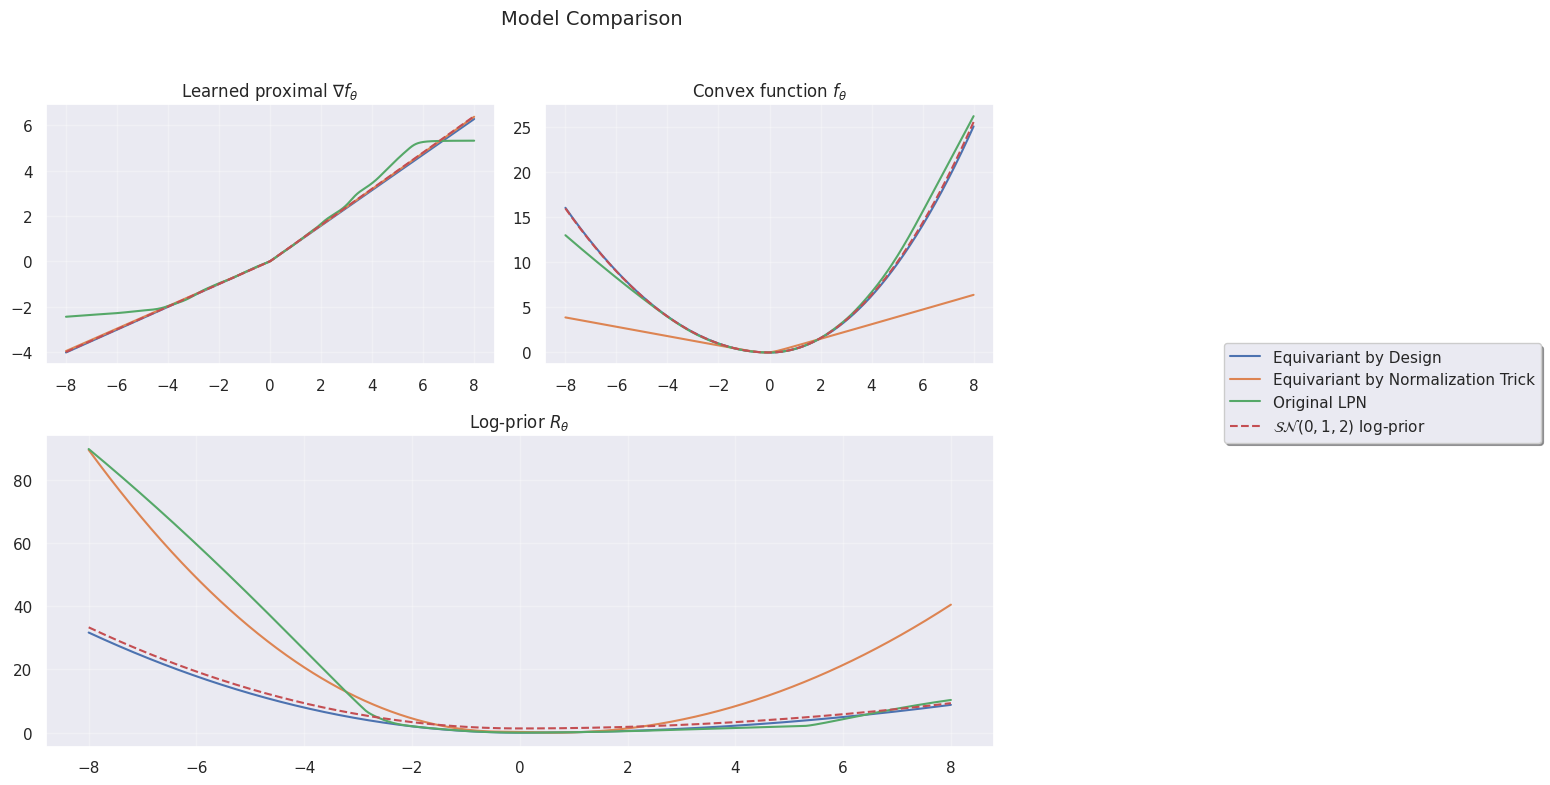

All models trained and plotted.


In [15]:
plot_comparison(trained_models)
print("All models trained and plotted.")